Task 1: Problem Identification

In [ ]:
# The dataset represents an Image Classification problem.

# Explanation

# The dataset contains product surface images categorized into four classes:

# normal
# scratch
# dent
# stain

# The objective of the model is to examine an input image and predict which single category it belongs to. Each image has only one label representing the overall condition of the product surface.

# In image classification:

# The entire image is treated as input.
# The model predicts one class label for the image.

# This matches the structure and goal of the given dataset

Task 2: Dataset Exploration

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

In [2]:
dataset_path = "images"

classes = ['normal', 'scratch', 'dent', 'stain']

In [3]:
num_classes = len(classes)

print("Number of Classes:", num_classes)
print("Classes:", classes)

Number of Classes: 4
Classes: ['normal', 'scratch', 'dent', 'stain']


In [4]:
image_count = {}

for class_name in classes:
    class_folder = os.path.join(dataset_path, class_name)
    image_count[class_name] = len(os.listdir(class_folder))

print(image_count)

{'normal': 120, 'scratch': 120, 'dent': 120, 'stain': 120}


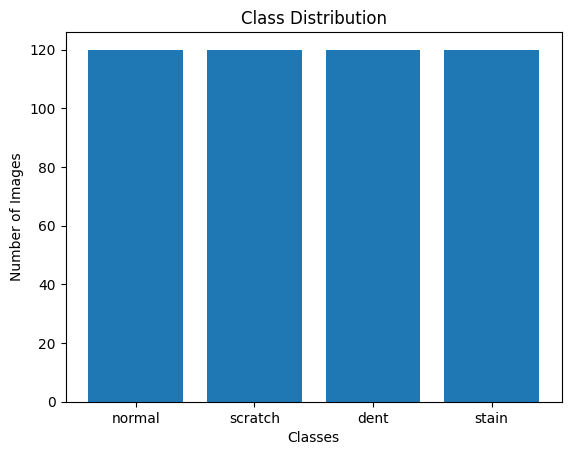

In [5]:
#Display Class Distribution
plt.bar(image_count.keys(), image_count.values())

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()


In [6]:
# Check Dataset Imbalance
print("Class Distribution:")

for class_name, count in image_count.items():
    print(f"{class_name}: {count}")

Class Distribution:
normal: 120
scratch: 120
dent: 120
stain: 120


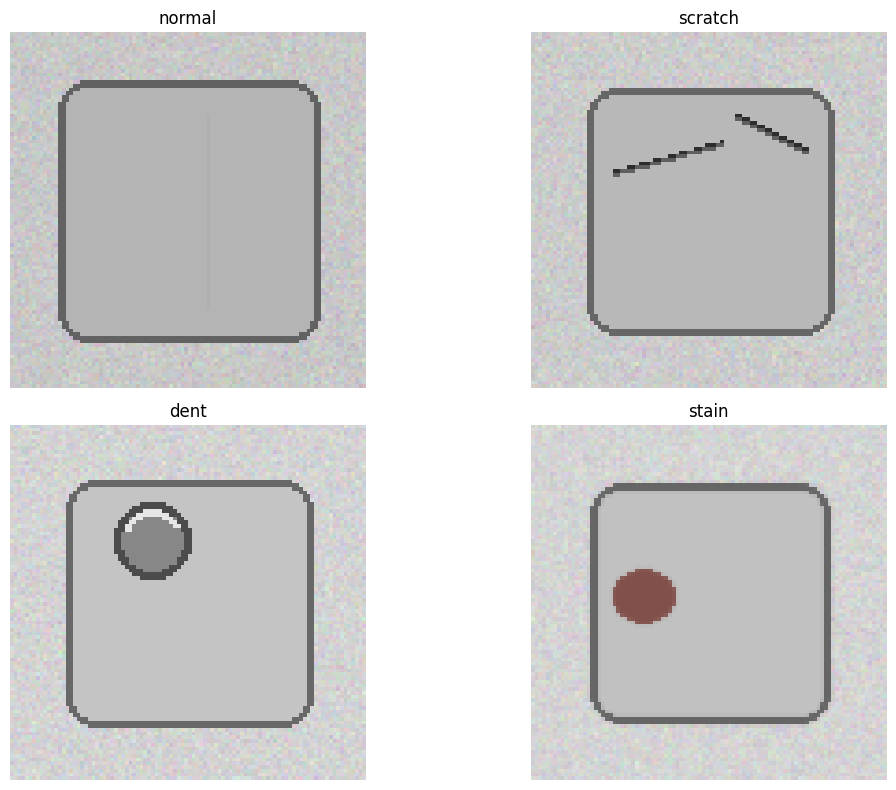

In [7]:
#Display Sample Images from Each Class
plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_folder)[0]

    image_path = os.path.join(class_folder, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [8]:
# Check Image Dimensions
for class_name in classes:

    class_folder = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_folder)[0]

    image_path = os.path.join(class_folder, image_name)

    image = cv2.imread(image_path)

    print(f"{class_name} Image Shape:", image.shape)

normal Image Shape: (96, 96, 3)
scratch Image Shape: (96, 96, 3)
dent Image Shape: (96, 96, 3)
stain Image Shape: (96, 96, 3)


Task 3: Image Preprocessing

In [9]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
dataset_path = "images"

classes = ['normal', 'scratch', 'dent', 'stain']

In [11]:
IMG_SIZE = 128

In [12]:
# Load and Resize Images
X = []
y = []

for label, class_name in enumerate(classes):

    class_folder = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_folder):

        image_path = os.path.join(class_folder, image_name)

        image = cv2.imread(image_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        X.append(image)

        y.append(label)

# Convert into NumPy arrays
X = np.array(X)
y = np.array(y)

print("Image Data Shape:", X.shape)
print("Label Shape:", y.shape)

Image Data Shape: (480, 128, 128, 3)
Label Shape: (480,)


In [13]:
X = X / 255.0

In [14]:
y = to_categorical(y, num_classes=4)

print(y[:5])

[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


In [15]:
# Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (384, 128, 128, 3)
Testing Shape: (96, 128, 128, 3)


In [16]:
# Apply Data Augmentation

# Data augmentation creates modified copies of images to improve CNN generalization and reduce overfitting.

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [17]:
# Fit Augmentation Generator
datagen.fit(X_train)

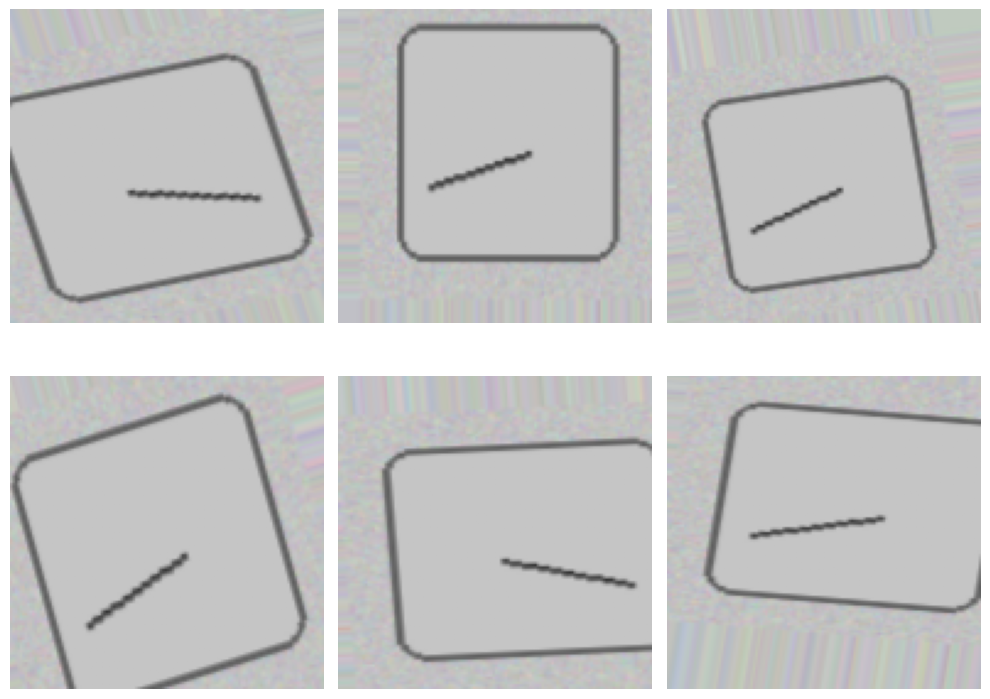

In [18]:
sample_image = X_train[0].reshape(1, IMG_SIZE, IMG_SIZE, 3)

plt.figure(figsize=(10,8))

for i, batch in enumerate(datagen.flow(sample_image, batch_size=1)):

    plt.subplot(2,3,i+1)

    plt.imshow(batch[0])

    plt.axis("off")

    if i == 5:
        break

plt.tight_layout()

plt.show()

Task 4: CNN Model Creation

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [20]:
# Create CNN Model
model = Sequential()

In [21]:
# Add Convolution Layer



model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

C:\Users\Ketki\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Add Pooling Layer

# Pooling reduces image dimensions and helps reduce computation.

model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [23]:
# Add Second Convolution + Pooling Layers
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [24]:
# Flatten Layer

# Flatten converts 2D feature maps into a 1D vector for dense layer processing.

model.add(Flatten())

In [25]:
#Dense Hidden Layer
model.add(
    Dense(
        units=128,
        activation='relu'
    )
)

In [26]:
model.add(
    Dense(
        units=4,
        activation='softmax'
    )
)

In [27]:
#Compile CNN Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
# Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train CNN Model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)

C:\Users\Ketki\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.2462 - loss: 2.4471 - val_accuracy: 0.2500 - val_loss: 1.3849
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2173 - loss: 1.3875 - val_accuracy: 0.3333 - val_loss: 1.3688
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3902 - loss: 1.3651 - val_accuracy: 0.3333 - val_loss: 1.3224
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4031 - loss: 1.2953 - val_accuracy: 0.5833 - val_loss: 1.1099
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4947 - loss: 1.1517 - val_accuracy: 0.5833 - val_loss: 1.0022
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5495 - loss: 1.0278 - val_accuracy: 0.5104 - val_loss: 1.0011
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5462 - loss: 1.0326 - val_accuracy: 0.6771 - val_loss: 0.9315
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5722 - loss: 0.9614 - val_accuracy: 0.7083 - val_loss:

In [30]:
# Evaluate CNN Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.7982 - loss: 0.4823
Test Loss: 0.45920529961586
Test Accuracy: 0.7916666865348816


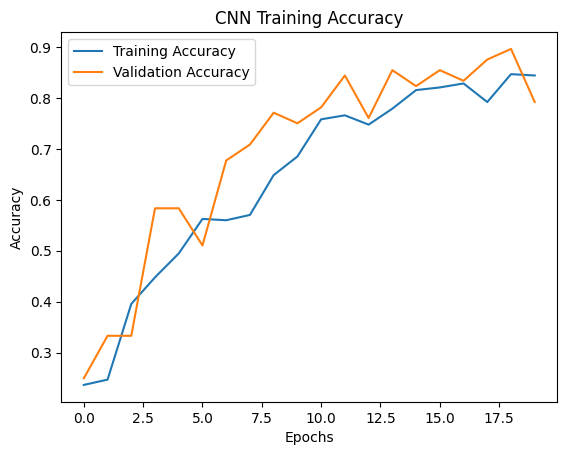

In [31]:
# Plot Training Accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("CNN Training Accuracy")

plt.legend()

In [32]:
plt.savefig("cnn_training_accuracy.png")

<Figure size 640x480 with 0 Axes>

Task 5: Model Training and Evaluation

In [33]:
# Train the CNN Model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8135 - loss: 0.4325 - val_accuracy: 0.9375 - val_loss: 0.2382
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8400 - loss: 0.4373 - val_accuracy: 0.8229 - val_loss: 0.3041
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8230 - loss: 0.4125 - val_accuracy: 0.8750 - val_loss: 0.3627
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8497 - loss: 0.4072 - val_accuracy: 0.9479 - val_loss: 0.2666
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9054 - loss: 0.3301 - val_accuracy: 0.8958 - val_loss: 0.2414
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7188 - loss: 0.6929 - val_accuracy: 0.9479 - val_loss: 0.6260
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8205 - loss: 0.6855 - val_accuracy: 0.8438 - val_loss: 0.4208
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7765 - loss: 0.5309 - val_accuracy: 0.8854 - val_loss:

In [34]:
# Training Accuracy and Loss
train_accuracy = history.history['accuracy']
train_loss = history.history['loss']

print("Training Accuracy:", train_accuracy[-1])
print("Training Loss:", train_loss[-1])

Training Accuracy: 0.921875
Training Loss: 0.22988615930080414


Validation Accuracy: 0.9479166865348816
Validation Loss: 0.11078495532274246


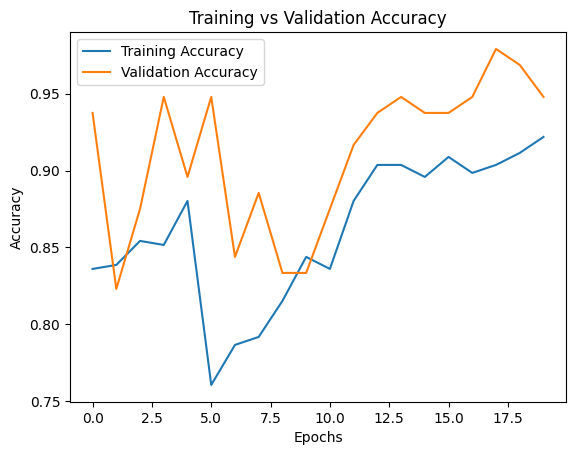

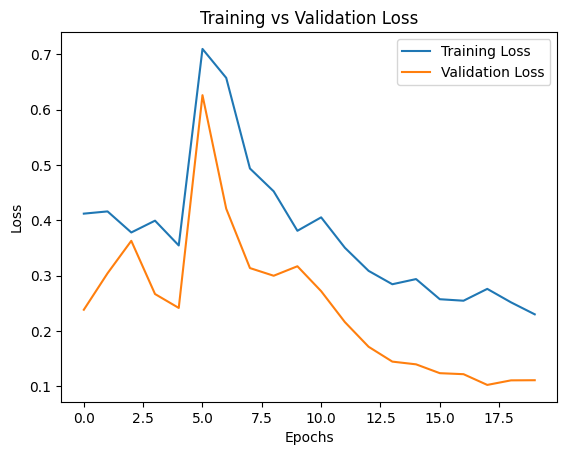

<Figure size 640x480 with 0 Axes>

In [37]:
# Validation Accuracy and Loss
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

print("Validation Accuracy:", val_accuracy[-1])
print("Validation Loss:", val_loss[-1])
# Plot Accuracy Graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()
# Plot Loss Graph
plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()
# Save Evaluation Graphs
plt.savefig("evaluation_outputs.png")

In [38]:
# Evaluate Testing Performance
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 822ms/step - accuracy: 0.9388 - loss: 0.1383
Test Accuracy: 0.9479166865348816
Test Loss: 0.11078495532274246


In [39]:
# Generate Predictions
predictions = model.predict(X_test)

predicted_classes = predictions.argmax(axis=1)

true_classes = y_test.argmax(axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step


In [40]:
# Create Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[24  0  0  0]
 [ 4 20  0  0]
 [ 0  1 23  0]
 [ 0  0  0 24]]


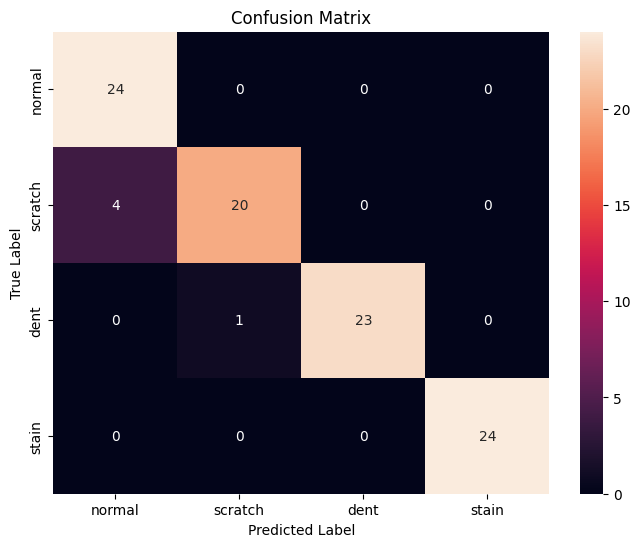

In [41]:
# Display Confusion Matrix
class_names = ['normal', 'scratch', 'dent', 'stain']

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

Task 6: CNN Concept Explanation

In [ ]:
# # CNN Concept Explanation

# ## What is Convolution?

# Convolution is the process where a small filter (kernel) moves across an image to detect important features such as edges, textures, scratches, dents, or patterns. The convolution layer helps the CNN automatically learn useful visual information from images.

# Convolution operation:

# (I*K)(x,y)=\sum_m\sum_n I(m,n)K(x-m,y-n)

# In manufacturing defect detection, convolution helps identify defects like scratches, stains, and dents on product surfaces.

# ---

# ## Why is Pooling Used?

# Pooling is used to reduce the size of feature maps generated by convolution layers. It helps:

# * reduce computation
# * reduce memory usage
# * prevent overfitting
# * retain important image features

# The most common pooling method is Max Pooling, which keeps the most important feature values from small regions of the image.

# Example:
# A 2×2 pooling operation selects the maximum value from each region.

# Pooling helps the CNN focus on important defect patterns while ignoring unnecessary details.

# ---

# ## Why is ReLU Commonly Used in CNNs?

# ReLU (Rectified Linear Unit) is an activation function widely used in CNNs because it introduces non-linearity and improves training speed.

# ReLU function:

# f(x)=\max(0,x)

# Advantages of ReLU:

# * Faster training
# * Reduces vanishing gradient problem
# * Improves deep learning performance
# * Simple and computationally efficient

# ReLU allows CNNs to learn complex visual patterns more effectively.

# ---

# ## Why are CNNs Better than Regular Feed-Forward Networks for Image Data?

# CNNs are specifically designed for image processing tasks. Unlike regular feed-forward neural networks, CNNs can automatically detect spatial and visual patterns in images.

# Advantages of CNNs:

# * Preserve image structure
# * Learn edges, textures, and shapes automatically
# * Require fewer parameters
# * Better feature extraction
# * More accurate for image classification tasks

# Regular feed-forward networks flatten images directly, which causes loss of spatial information. CNNs maintain spatial relationships between pixels, making them much more effective for computer vision applications such as defect detection, facial recognition, and medical imaging.

# In this project, CNNs help identify manufacturing defects by learning visual characteristics from product images automatically.


Task 7: Business Use Case Mapping

In [ ]:
# # Business Use Case Mapping

# ## Manufacturing Industry Application

# This computer vision solution can be widely used in the manufacturing industry for automated quality inspection. In large-scale production environments, products are manufactured continuously, and manual inspection of every product is time-consuming, expensive, and prone to human error.

# Using Convolutional Neural Networks (CNNs), cameras can automatically capture product images and classify them into categories such as:

# * normal
# * scratch
# * dent
# * stain

# The trained CNN model can quickly identify defective products in real time and help manufacturers remove faulty items before packaging or delivery.

# ### Benefits of Using CNN-Based Quality Inspection

# * Reduces manual inspection effort
# * Improves production speed
# * Increases defect detection accuracy
# * Reduces operational costs
# * Minimizes defective product delivery
# * Supports industrial automation

# ### Real-World Examples

# Many industries use computer vision systems for quality control, including:

# * automobile manufacturing
# * electronics production
# * metal surface inspection
# * textile quality checking
# * food packaging industries

# For example, in automobile manufacturing, CNN-based inspection systems can detect scratches or dents on car body parts before assembly. This improves product quality and customer satisfaction.

# Overall, CNN-based computer vision systems play an important role in smart manufacturing and Industry 4.0 automation technologies.


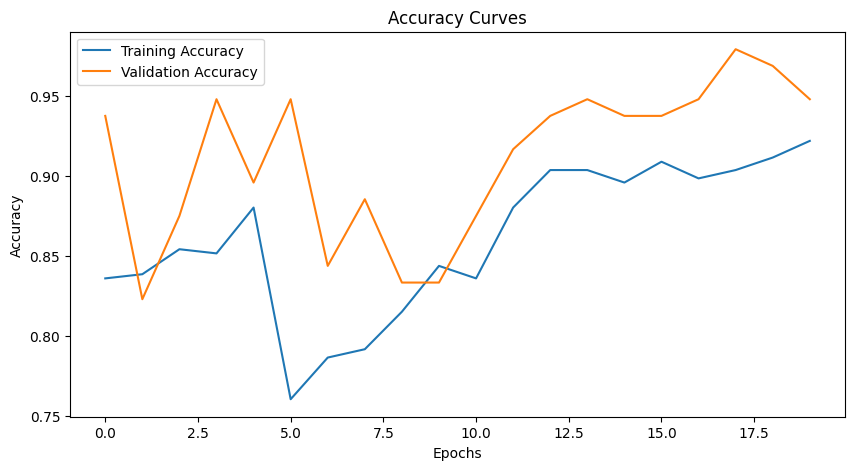

In [43]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.savefig("accuracy_loss_curves.png")

plt.show()

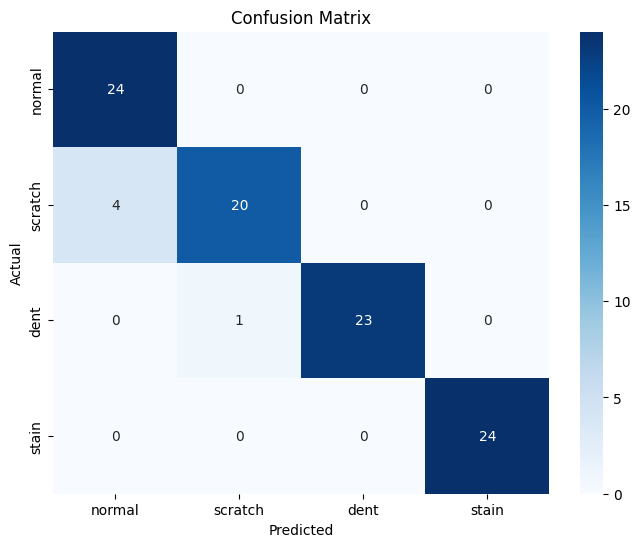

In [44]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

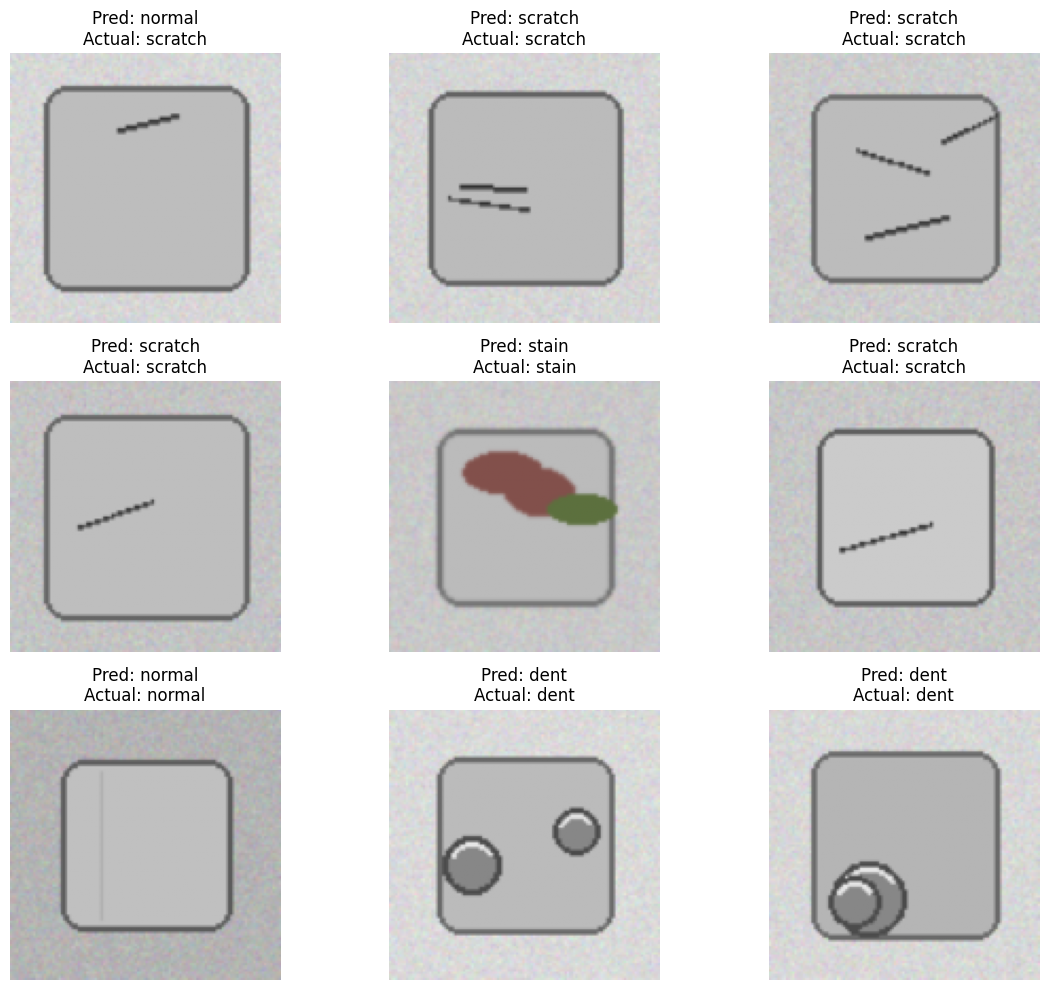

In [45]:
plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    pred = class_names[predicted_classes[i]]

    actual = class_names[true_classes[i]]

    plt.title(f"Pred: {pred}\nActual: {actual}")

    plt.axis("off")

plt.tight_layout()

plt.savefig("prediction_outputs.png")

plt.show()